In [1]:
#importing libraries

In [2]:
import pandas as pd
import numpy as np
import os

In [3]:
#import data from my disk

In [4]:
nav = pd.read_csv("C:/Users/Bhanu Bisht/Data_Analytics_Project/data/raw/02_nav_history.csv")

In [5]:
nav.head()

,amfi_code,date,nav
0,119551,2022-01-03,54.3856
1,119551,2022-01-04,54.3474
2,119551,2022-01-05,54.6869
3,119551,2022-01-06,55.4550
4,119551,2022-01-07,55.3692


In [6]:
nav.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46000 entries, 0 to 45999
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   amfi_code  46000 non-null  int64  
 1   date       46000 non-null  object 
 2   nav        46000 non-null  float64
dtypes: float64(1), int64(1), object(1)
memory usage: 1.1+ MB


In [7]:
nav.describe()

,amfi_code,nav
count,46000.000000,46000.000000
mean,120247.000000,269.570265
std,14352.317221,577.187060
min,100016.000000,26.136600
25%,118632.750000,69.170425
50%,119551.500000,122.732150
75%,120842.250000,260.338675
max,149324.000000,4268.549700


In [8]:
nav.shape

(46000, 3)

In [9]:
nav.dtypes

amfi_code      int64
date          object
nav          float64
dtype: object

In [10]:
nav.columns

Index(['amfi_code', 'date', 'nav'], dtype='object')

In [11]:
# date dtype is object change in datetime

In [12]:
## 1. Parse dates
nav['date'] = pd.to_datetime(nav['date'])

In [13]:
nav['date']

0       2022-01-03
1       2022-01-04
2       2022-01-05
3       2022-01-06
4       2022-01-07
           ...    
45995   2026-05-25
45996   2026-05-26
45997   2026-05-27
45998   2026-05-28
45999   2026-05-29
Name: date, Length: 46000, dtype: datetime64[ns]

In [14]:
nav.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46000 entries, 0 to 45999
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   amfi_code  46000 non-null  int64         
 1   date       46000 non-null  datetime64[ns]
 2   nav        46000 non-null  float64       
dtypes: datetime64[ns](1), float64(1), int64(1)
memory usage: 1.1 MB


# Fund Performance Analytics

# 1st instruction according to project

# Compute daily returns — daily_return = nav_t / nav_t-1 − 1 for all 40 schemes. Validate distribution looks reasonable.

In [15]:
# Step 1: Check the number of schemes

In [16]:
nav["amfi_code"].nunique()

40

In [17]:
# Step 2: Sort the data

In [18]:
nav = nav.sort_values(["amfi_code", "date"])

In [19]:
nav.head(2)

,amfi_code,date,nav
5750,100016,2022-01-03,520.4608
5751,100016,2022-01-04,515.0971


In [20]:
# Step 3: Compute Daily Returns

In [21]:
nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
          .pct_change()
)

In [22]:
nav['daily_return']

5750          NaN
5751    -0.010306
5752     0.012865
5753    -0.011377
5754    -0.001210
           ...   
45995    0.012106
45996   -0.004138
45997   -0.008480
45998   -0.028093
45999   -0.003335
Name: daily_return, Length: 46000, dtype: float64

In [23]:
# The first row of each scheme is NaN because there is no previous NAV

In [24]:
nav.head(10)

,amfi_code,date,nav,daily_return
5750,100016,2022-01-03,520.4608,NaN
5751,100016,2022-01-04,515.0971,-0.010306
5752,100016,2022-01-05,521.7239,0.012865
5753,100016,2022-01-06,515.7880,-0.011377
5754,100016,2022-01-07,515.1639,-0.001210
5755,100016,2022-01-10,510.7136,-0.008639
5756,100016,2022-01-11,513.5542,0.005562
5757,100016,2022-01-12,512.3195,-0.002404
5758,100016,2022-01-13,510.2445,-0.004050
5759,100016,2022-01-14,514.3636,0.008073


In [25]:
# Step 4: Validate the Distribution

In [26]:
nav["daily_return"].describe()

count    45960.000000
mean         0.000631
std          0.010290
min         -0.058102
25%         -0.005042
50%          0.000340
75%          0.006324
max          0.064713
Name: daily_return, dtype: float64

In [27]:
#Histogram

In [28]:
# we use matplotlib library for data visualization

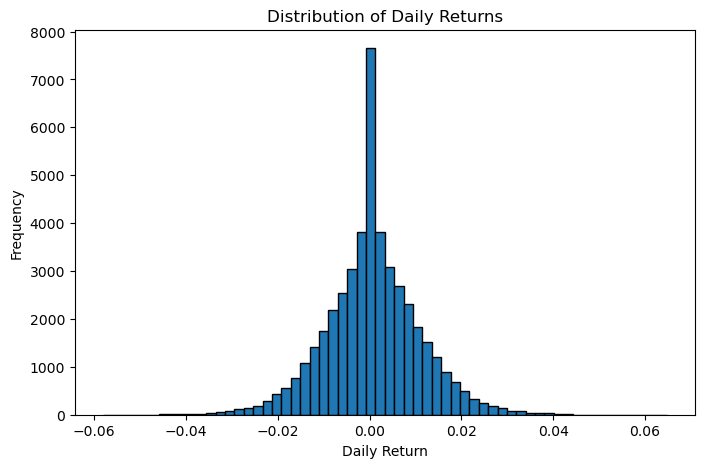

In [29]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(
    nav["daily_return"].dropna(),
    bins=60,
    edgecolor="black"
)

plt.title("Distribution of Daily Returns")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")

plt.show()

In [30]:
# Boxplot

In [31]:
# This helps identify outliers

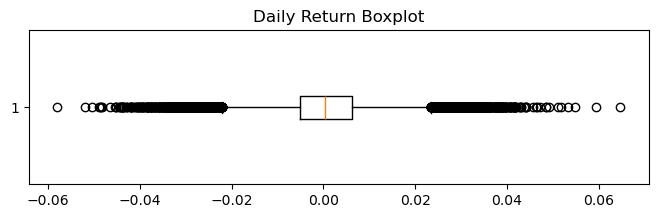

In [32]:
plt.figure(figsize=(8,2))

plt.boxplot(nav["daily_return"].dropna(), vert=False)

plt.title("Daily Return Boxplot")

plt.show()

In [33]:
# Check extreme values

#Largest positive returns:

In [34]:
nav.nlargest(10, "daily_return")

,amfi_code,date,nav,daily_return
2895,119598,2024-04-15,189.0742,0.064713
20126,118634,2024-03-19,110.5401,0.059304
33957,101207,2024-05-01,65.5882,0.054851
3716,119599,2023-01-10,153.2221,0.053320
3982,119599,2024-01-17,136.8239,0.051811
2305,119598,2022-01-10,96.0964,0.051113
2521,119598,2022-11-08,123.9704,0.049051
45082,149324,2022-11-23,98.3696,0.048490
2506,119598,2022-10-18,122.2757,0.048454
3241,119598,2025-08-12,200.8460,0.047123


In [35]:
# Largest negative returns:

In [36]:
nav.nsmallest(10, "daily_return")

,amfi_code,date,nav,daily_return
19674,118634,2022-06-24,67.2534,-0.058102
33667,101207,2023-03-22,56.8326,-0.051847
19852,118634,2023-03-01,113.5801,-0.050335
45312,149324,2023-10-11,111.8155,-0.048870
34310,101207,2025-09-08,62.3200,-0.048634
31304,119095,2022-12-23,73.9946,-0.048367
20233,118634,2024-08-15,114.5168,-0.048305
31807,119095,2024-11-27,78.1317,-0.046524
4198,119599,2024-11-14,112.8996,-0.045429
9770,125498,2024-03-11,131.4556,-0.045218


In [37]:
# Check missing values

In [38]:
nav["daily_return"].isna().sum()

np.int64(40)

# 2nd instruction according to project

In [39]:
# Compute CAGR for 1yr, 3yr, 5yr — CAGR = (NAV_end / NAV_start) ^ (1/n) − 1. Build a comparison table across all funds.

In [40]:
# You need to calculate the Compound Annual Growth Rate (CAGR) for each mutual fund scheme over:
#1 year
# 3 years
# 5 years

In [41]:
# Step 1: Sort the data

In [42]:
nav = nav.sort_values(["amfi_code", "date"])

In [43]:
nav.head(2)

,amfi_code,date,nav,daily_return
5750,100016,2022-01-03,520.4608,NaN
5751,100016,2022-01-04,515.0971,-0.010306


In [44]:
# Step 2: Get the latest date

In [45]:
latest_date = nav["date"].max()
print(latest_date)

2026-05-29 00:00:00


In [46]:
# Step 3: Create start dates

In [47]:

date_1y = latest_date - pd.DateOffset(years=1)
date_3y = latest_date - pd.DateOffset(years=3)
date_5y = latest_date - pd.DateOffset(years=5)

In [48]:
# Step 4: Create a function to calculate CAGR

In [49]:
def calculate_cagr(nav, years):
    latest_date = nav["date"].max()
    start_date = latest_date - pd.DateOffset(years=years)

    result = []

    for scheme, group in nav.groupby("amfi_code"):

        group = group.sort_values("date")

        # first NAV on/after start date
        start = group[group["date"] >= start_date].head(1)

        # latest NAV
        end = group.tail(1)

        if start.empty or end.empty:
            continue

        nav_start = start["nav"].values[0]
        nav_end = end["nav"].values[0]

        cagr = (nav_end / nav_start) ** (1 / years) - 1

        result.append({
            "amfi_code": scheme,
            f"CAGR_{years}Y": cagr
        })

    return pd.DataFrame(result)

In [50]:
# Step 5: Calculate all three

In [51]:
cagr_1 = calculate_cagr(nav, 1)
cagr_3 = calculate_cagr(nav, 3)
cagr_5 = calculate_cagr(nav, 5)

In [52]:
# Step 6: Build the comparison table

In [53]:
cagr_table = (
    cagr_1
    .merge(cagr_3, on="amfi_code")
    .merge(cagr_5, on="amfi_code")
)

In [54]:
# Step 7: Convert to percentages

In [55]:
cagr_table.iloc[:, 1:] *= 100

cagr_table.iloc[:, 1:] = cagr_table.iloc[:, 1:].round(2)

In [56]:
# Step 8: View the result

In [57]:
cagr_table.head()

,amfi_code,CAGR_1Y,CAGR_3Y,CAGR_5Y
0,100016,-2.22,1.29,2.32
1,100025,3.70,3.92,3.91
2,100033,53.23,32.44,26.07
3,101206,47.92,28.97,20.44
4,101207,-23.99,-4.15,6.95


# 3rd instruction according to project 

In [58]:
# Sharpe Ratio — (Rp − Rf) / Std(Rp) × √252. Use Rf = 6.5% (RBI repo rate proxy). Rank all 40 funds

In [59]:
# Sharpe Ratio = (Rp − Rf) / Std(Rp) × √252

# Use Rf = 6.5% (risk-free rate).

#Rank all 40 funds.

In [60]:
#Calculate the average daily return for each scheme.
#Calculate the daily return standard deviation (volatility) for each scheme.
#Convert the annual risk-free rate (6.5%) to a daily risk-free rate.
#Calculate the Sharpe Ratio.
#Rank all schemes from highest to lowest Sharpe Ratio.

In [61]:
# Step 1:  dataframe

In [62]:
nav

,amfi_code,date,nav,daily_return
5750,100016,2022-01-03,520.4608,NaN
5751,100016,2022-01-04,515.0971,-0.010306
5752,100016,2022-01-05,521.7239,0.012865
5753,100016,2022-01-06,515.7880,-0.011377
5754,100016,2022-01-07,515.1639,-0.001210
...,...,...,...,...
45995,149324,2026-05-25,292.4810,0.012106
45996,149324,2026-05-26,291.2707,-0.004138
45997,149324,2026-05-27,288.8007,-0.008480
45998,149324,2026-05-28,280.6873,-0.028093


In [63]:
# Step 1: Set the Risk-Free Rate
# Use Rf = 6.5% (RBI repo rate proxy)

In [64]:
rf = 0.065          # Annual risk-free rate (6.5%)
daily_rf = rf / 252 # Convert annual rate to daily rate

In [65]:
# Step 3: Calculate Mean Return and Standard Deviation

In [66]:
# Group the data by amfi_code and calculate the average and standard deviation of daily returns.

In [67]:
sharpe_df = (
    nav.groupby("amfi_code")["daily_return"]
       .agg(
           mean_return="mean",
           std_return="std"
       )
       .reset_index()
)

In [68]:
sharpe_df.head(2)

,amfi_code,mean_return,std_return
0,100016,0.000142,0.009164
1,100025,0.000170,0.002460


In [69]:
# Step 4: Calculate Sharpe Ratio

In [70]:
# # Sharpe Ratio = (Rp − Rf) / Std(Rp) × √252

In [71]:
sharpe_df["Sharpe_Ratio"] = (
    (sharpe_df["mean_return"] - daily_rf)
    / sharpe_df["std_return"]
) * np.sqrt(252)

In [72]:
# Step 5: Rank All Funds

In [73]:
# Higher Sharpe Ratio = Better performance.

In [74]:
sharpe_df["Rank"] = (
    sharpe_df["Sharpe_Ratio"]
        .rank(method="dense", ascending=False)
        .astype(int)
)

In [75]:
# Step 6: Sort by Rank

In [76]:
sharpe_df = sharpe_df.sort_values("Rank")

In [77]:
# Step 7: View the Results

In [78]:
sharpe_df.head(10)

,amfi_code,mean_return,std_return,Sharpe_Ratio,Rank
34,148567,0.001074,0.008941,1.448291,1
30,120843,0.001082,0.010008,1.306744,2
36,148569,0.001124,0.011134,1.234930,3
19,119551,0.000917,0.008656,1.208267,4
25,120505,0.001161,0.012152,1.180101,5
38,149323,0.001055,0.011179,1.132122,6
2,100033,0.001080,0.011929,1.093699,7
9,118632,0.000865,0.008913,1.081659,8
3,101206,0.000852,0.009177,1.027213,9
24,120504,0.000843,0.009048,1.026524,10


In [79]:
# Step 8 Round the Values
# This rounds mean_return &  std_return & Sharpe_Ratio to 6 decimal places.

In [80]:
sharpe_df["mean_return"] = sharpe_df["mean_return"].round(6)
sharpe_df["std_return"] = sharpe_df["std_return"].round(6)
sharpe_df["Sharpe_Ratio"] = sharpe_df["Sharpe_Ratio"].round(3)

In [81]:
sharpe_df.head(5)

,amfi_code,mean_return,std_return,Sharpe_Ratio,Rank
34,148567,0.001074,0.008941,1.448,1
30,120843,0.001082,0.010008,1.307,2
36,148569,0.001124,0.011134,1.235,3
19,119551,0.000917,0.008656,1.208,4
25,120505,0.001161,0.012152,1.180,5


# instruction 4 according to project

In [82]:
#Sortino Ratio — same formula but denominator uses only downside standard deviation (negative return days only).

In [83]:
# Step 1: Define downside standard deviation

In [84]:
def downside_std(x):
    negative_returns = x[x < 0]
    return negative_returns.std()

In [85]:
# Step 2: Calculate mean return and downside standard deviation

In [86]:


rf_annual = 0.065
rf_daily = rf_annual / 252

sortino_df = nav.groupby("amfi_code").agg(
    mean_return=("daily_return", "mean")
).reset_index()

# Downside standard deviation
sortino_df["downside_std"] = (
    nav.groupby("amfi_code")["daily_return"]
       .apply(downside_std)
       .values
)

In [87]:
# Step 3: Calculate Sortino Ratio

In [88]:
sortino_df["Sortino_Ratio"] = (
    (sortino_df["mean_return"] - rf_daily)
    / sortino_df["downside_std"]
) * np.sqrt(252)

In [89]:
# Step 4: Rank the funds

In [90]:
sortino_df = sortino_df.sort_values(
    "Sortino_Ratio",
    ascending=False
).reset_index(drop=True)

sortino_df["Rank"] = sortino_df.index + 1

In [91]:
#Step 5: Display the result

In [92]:
sortino_df.head(2)

,amfi_code,mean_return,downside_std,Sortino_Ratio,Rank
0,148567,0.001074,0.005428,2.385644,1
1,120843,0.001082,0.005531,2.364320,2


In [93]:
sharpe_df.head(2)

,amfi_code,mean_return,std_return,Sharpe_Ratio,Rank
34,148567,0.001074,0.008941,1.448,1
30,120843,0.001082,0.010008,1.307,2


In [94]:
nav.head(2)

,amfi_code,date,nav,daily_return
5750,100016,2022-01-03,520.4608,NaN
5751,100016,2022-01-04,515.0971,-0.010306


# instruction 5th according to instruction

In [95]:
#Alpha and Beta — OLS regression of fund returns on Nifty 100 returns using scipy.stats.linregress. Alpha = intercept × 252.

In [96]:
#Alpha and Beta (OLS Regression)

In [97]:
# import benchmark dataset

In [98]:
benchmark = pd.read_csv("C:/Users/Bhanu Bisht/Data_Analytics_Project/data/raw/10_benchmark_indices.csv")

In [99]:
benchmark.head(2)

,date,index_name,close_value
0,2022-01-03,NIFTY50,17492.79
1,2022-01-04,NIFTY50,17689.64


In [100]:
benchmark["index_name"].unique()

array(['NIFTY50', 'NIFTY100', 'NIFTY_MIDCAP150', 'BSE_SMALLCAP',
       'NIFTY500', 'CRISIL_LIQUID', 'CRISIL_GILT'], dtype=object)

In [101]:
benchmark.dtypes

date            object
index_name      object
close_value    float64
dtype: object

In [102]:
# date dtype is object change in datetime

In [103]:
## 1. Parse dates
benchmark['date'] = pd.to_datetime(benchmark['date'])

In [104]:
benchmark['date'].head()

0   2022-01-03
1   2022-01-04
2   2022-01-05
3   2022-01-06
4   2022-01-07
Name: date, dtype: datetime64[ns]

In [105]:
benchmark.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8050 entries, 0 to 8049
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   date         8050 non-null   datetime64[ns]
 1   index_name   8050 non-null   object        
 2   close_value  8050 non-null   float64       
dtypes: datetime64[ns](1), float64(1), object(1)
memory usage: 188.8+ KB


In [106]:
nav.info()

<class 'pandas.core.frame.DataFrame'>
Index: 46000 entries, 5750 to 45999
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   amfi_code     46000 non-null  int64         
 1   date          46000 non-null  datetime64[ns]
 2   nav           46000 non-null  float64       
 3   daily_return  45960 non-null  float64       
dtypes: datetime64[ns](1), float64(2), int64(1)
memory usage: 1.8 MB


In [107]:
benchmark.head(2)

,date,index_name,close_value
0,2022-01-03,NIFTY50,17492.79
1,2022-01-04,NIFTY50,17689.64


In [108]:
nav.head(2)

,amfi_code,date,nav,daily_return
5750,100016,2022-01-03,520.4608,NaN
5751,100016,2022-01-04,515.0971,-0.010306


In [109]:
nav["daily_return"].unique()

array([        nan, -0.01030568,  0.01286515, ..., -0.00848008,
       -0.02809342, -0.00333538])

In [110]:
benchmark["index_name"].value_counts()

index_name
NIFTY50            1150
NIFTY100           1150
NIFTY_MIDCAP150    1150
BSE_SMALLCAP       1150
NIFTY500           1150
CRISIL_LIQUID      1150
CRISIL_GILT        1150
Name: count, dtype: int64

In [111]:
#Step 1: Filter NIFTY100

In [112]:
nifty100 = benchmark[benchmark["index_name"] == "NIFTY100"].copy()

In [113]:
nifty100.head(2)

,date,index_name,close_value
1150,2022-01-03,NIFTY100,17778.24
1151,2022-01-04,NIFTY100,17537.52


In [114]:
#Step 2: Calculate benchmark daily returns

In [115]:
nifty100["benchmark_return"] = nifty100["close_value"].pct_change()

In [116]:
nifty100.head(2)

,date,index_name,close_value,benchmark_return
1150,2022-01-03,NIFTY100,17778.24,NaN
1151,2022-01-04,NIFTY100,17537.52,-0.01354


In [117]:
#Step 3: Keep required columns

In [118]:
nifty100 = nifty100[["date", "benchmark_return"]]

In [119]:
nifty100 

,date,benchmark_return
1150,2022-01-03,NaN
1151,2022-01-04,-0.013540
1152,2022-01-05,0.004003
1153,2022-01-06,-0.002935
1154,2022-01-07,0.006150
...,...,...
2295,2026-05-25,0.002732
2296,2026-05-26,-0.000912
2297,2026-05-27,0.013582
2298,2026-05-28,0.009684


In [120]:
#Step 4: Merge with NAV data

In [121]:
merged = pd.merge(
    nav,
    nifty100,
    on="date",
    how="inner"
)

In [122]:
merged.head(3)

,amfi_code,date,nav,daily_return,benchmark_return
0,100016,2022-01-03,520.4608,NaN,NaN
1,100016,2022-01-04,515.0971,-0.010306,-0.013540
2,100016,2022-01-05,521.7239,0.012865,0.004003


In [123]:
#Step 5: Remove missing values

In [124]:
merged = merged.dropna(subset=["daily_return", "benchmark_return"])

In [125]:
merged.isna().sum()

amfi_code           0
date                0
nav                 0
daily_return        0
benchmark_return    0
dtype: int64

In [126]:
#Step 6: Calculate Alpha & Beta for every fund

In [127]:
from scipy.stats import linregress
import pandas as pd

alpha_beta = []

for code in merged["amfi_code"].unique():

    fund = merged[merged["amfi_code"] == code]

    result = linregress(
        fund["benchmark_return"],
        fund["daily_return"]
    )

    alpha_beta.append({
        "amfi_code": code,
        "beta": result.slope,
        "daily_alpha": result.intercept,
        "annual_alpha": result.intercept * 252,
        "r_squared": result.rvalue ** 2,
        "p_value": result.pvalue
    })

alpha_beta = pd.DataFrame(alpha_beta)

alpha_beta.head()

,amfi_code,beta,daily_alpha,annual_alpha,r_squared,p_value
0,100016,-0.058268,0.000149,0.037476,0.002665,0.080264
1,100025,0.001158,0.000170,0.042818,0.000015,0.897012
2,100033,0.005104,0.001079,0.271954,0.000012,0.906369
3,101206,0.021086,0.000849,0.213998,0.000348,0.527551
4,101207,-0.065289,0.000432,0.108971,0.001064,0.269234


# 6th isntruction according to project

In [128]:
# Maximum Drawdown — min(NAV / running_max − 1) for each fund. Find worst drawdown date range.

In [129]:
#Maximum Drawdown

In [130]:
#Step 1: Sort data

In [131]:
nav = nav.sort_values(
    ["amfi_code", "date"]
)

In [132]:
nav

,amfi_code,date,nav,daily_return
5750,100016,2022-01-03,520.4608,NaN
5751,100016,2022-01-04,515.0971,-0.010306
5752,100016,2022-01-05,521.7239,0.012865
5753,100016,2022-01-06,515.7880,-0.011377
5754,100016,2022-01-07,515.1639,-0.001210
...,...,...,...,...
45995,149324,2026-05-25,292.4810,0.012106
45996,149324,2026-05-26,291.2707,-0.004138
45997,149324,2026-05-27,288.8007,-0.008480
45998,149324,2026-05-28,280.6873,-0.028093


In [133]:
#Step 2: Calculate Running Maximum NAV

In [134]:
nav["running_max"] = (
    nav.groupby("amfi_code")["nav"]
       .cummax()
)

In [135]:
nav["running_max"]

5750     520.4608
5751     520.4608
5752     521.7239
5753     521.7239
5754     521.7239
           ...   
45995    336.6937
45996    336.6937
45997    336.6937
45998    336.6937
45999    336.6937
Name: running_max, Length: 46000, dtype: float64

In [136]:
#Step 3: Calculate Drawdown

In [137]:
nav["drawdown"] = (
    nav["nav"] /
    nav["running_max"]
) - 1

In [138]:
nav['drawdown']

5750     0.000000
5751    -0.010306
5752     0.000000
5753    -0.011377
5754    -0.012574
           ...   
45995   -0.131314
45996   -0.134909
45997   -0.142245
45998   -0.166342
45999   -0.169123
Name: drawdown, Length: 46000, dtype: float64

In [139]:
#Step 4: Maximum Drawdown for each fund

In [140]:
max_drawdown = (
    nav.groupby("amfi_code")["drawdown"]
       .min()
       .reset_index()
)

max_drawdown.rename(
    columns={"drawdown": "max_drawdown"},
    inplace=True
)

max_drawdown.head()

,amfi_code,max_drawdown
0,100016,-0.247344
1,100025,-0.043083
2,100033,-0.162172
3,101206,-0.112916
4,101207,-0.354469


In [141]:
#Step 5: Find the worst drawdown date

In [142]:
#Find the row where the drawdown reaches its minimum for each fund:

In [143]:
worst_drawdown = (
    nav.loc[
        nav.groupby("amfi_code")["drawdown"].idxmin(),
        ["amfi_code", "date", "drawdown"]
    ]
)

worst_drawdown.rename(
    columns={
        "date": "worst_drawdown_date",
        "drawdown": "max_drawdown"
    },
    inplace=True
)

worst_drawdown.head()

,amfi_code,worst_drawdown_date,max_drawdown
5933,100016,2022-09-15,-0.247344
10759,100025,2023-07-28,-0.043083
8143,100033,2022-05-12,-0.162172
32592,101206,2023-07-05,-0.112916
34485,101207,2026-05-11,-0.354469


In [144]:
# step 6 Find the full drawdown period (Peak → Trough)

In [145]:
drawdown_ranges = []

for code, fund in nav.groupby("amfi_code"):

    fund = fund.sort_values("date").copy()

    fund["running_max"] = fund["nav"].cummax()
    fund["drawdown"] = fund["nav"] / fund["running_max"] - 1

    trough_idx = fund["drawdown"].idxmin()
    trough_date = fund.loc[trough_idx, "date"]
    max_drawdown = fund.loc[trough_idx, "drawdown"]

    peak_nav = fund.loc[trough_idx, "running_max"]

    peak_date = fund[
        (fund["nav"] == peak_nav) &
        (fund["date"] <= trough_date)
    ]["date"].max()

    drawdown_ranges.append({
        "amfi_code": code,
        "peak_date": peak_date,
        "trough_date": trough_date,
        "max_drawdown": max_drawdown
    })

drawdown_ranges = pd.DataFrame(drawdown_ranges)

drawdown_ranges.head()

,amfi_code,peak_date,trough_date,max_drawdown
0,100016,2022-03-30,2022-09-15,-0.247344
1,100025,2023-05-23,2023-07-28,-0.043083
2,100033,2022-03-11,2022-05-12,-0.162172
3,101206,2023-04-24,2023-07-05,-0.112916
4,101207,2024-11-21,2026-05-11,-0.354469


## 7th instruction

In [146]:
## Fund Scorecard (0–100) — composite: 30% × 3yr return rank + 25% × Sharpe rank + 20% × Alpha rank + 15% × expense ratio rank (inverse) + 10% × max DD rank (inverse).

In [147]:
fund_master= pd.read_csv("C:/Users/Bhanu Bisht/Data_Analytics_Project/data/raw/01_fund_master.csv")

In [148]:
fund_master.head(2)

,amfi_code,fund_house,scheme_name,category,sub_category,plan,launch_date,benchmark,expense_ratio_pct,exit_load_pct,min_sip_amount,min_lumpsum_amount,fund_manager,risk_category,sebi_category_code
0,119551,SBI Mutual Fund,SBI Bluechip Fund - Regular Plan - Growth,Equity,Large Cap,Regular,14-02-2006,NIFTY 100 TRI,1.54,1.0,500,1000,Sohini Andani,Moderate,EC01
1,119552,SBI Mutual Fund,SBI Bluechip Fund - Direct Plan - Growth,Equity,Large Cap,Direct,01-01-2013,NIFTY 100 TRI,0.66,1.0,500,1000,Sohini Andani,Moderate,EC01


In [149]:
fund_master.columns

Index(['amfi_code', 'fund_house', 'scheme_name', 'category', 'sub_category',
       'plan', 'launch_date', 'benchmark', 'expense_ratio_pct',
       'exit_load_pct', 'min_sip_amount', 'min_lumpsum_amount', 'fund_manager',
       'risk_category', 'sebi_category_code'],
      dtype='object')

In [167]:
#Step 2: Calculate the 3-Year Return

In [168]:
nav = nav.sort_values(["amfi_code", "date"])

In [170]:
return_3yr = (
    nav.groupby("amfi_code")
       .agg(
           start_nav=("nav", "first"),
           end_nav=("nav", "last")
       )
       .reset_index()
)

In [171]:
return_3yr["return_3yr"] = (
    return_3yr["end_nav"] /
    return_3yr["start_nav"]
) - 1

In [172]:
return_3yr = return_3yr[
    ["amfi_code", "return_3yr"]
]

In [173]:
return_3yr.head()

,amfi_code,return_3yr
0,100016,0.121336
1,100025,0.211552
2,100033,2.185142
3,101206,1.534562
4,101207,0.399496


In [150]:

# Keep only required columns and rename
sharpe_ratio = sharpe_df[["amfi_code", "Sharpe_Ratio"]].rename(
    columns={"Sharpe_Ratio": "sharpe"}
)

print(sharpe_ratio.head())  

    amfi_code  sharpe
34     148567   1.448
30     120843   1.307
36     148569   1.235
19     119551   1.208
25     120505   1.180


In [151]:
#Step 4: Prepare Alpha

#From your regression results:

In [152]:
alpha = alpha_beta[
    ["amfi_code", "annual_alpha"]
]

In [153]:
alpha.head()

,amfi_code,annual_alpha
0,100016,0.037476
1,100025,0.042818
2,100033,0.271954
3,101206,0.213998
4,101207,0.108971


In [154]:
#Step 5: Prepare Maximum Drawdown

In [158]:
drawdown_ranges.head(5)

,amfi_code,peak_date,trough_date,max_drawdown
0,100016,2022-03-30,2022-09-15,-0.247344
1,100025,2023-05-23,2023-07-28,-0.043083
2,100033,2022-03-11,2022-05-12,-0.162172
3,101206,2023-04-24,2023-07-05,-0.112916
4,101207,2024-11-21,2026-05-11,-0.354469


In [159]:
# Step 6: Prepare Expense Ratio

In [160]:
# From your metadata DataFrame:

In [162]:
expense = fund_master[
    ["amfi_code", "expense_ratio_pct"]
]

In [164]:
expense.head()

,amfi_code,expense_ratio_pct
0,119551,1.54
1,119552,0.66
2,119598,1.43
3,119599,0.72
4,119120,0.77


In [165]:
#Step 7: Merge all metrics

In [174]:
scorecard = (
    return_3yr
    .merge(sharpe_ratio, on="amfi_code")
    .merge(alpha, on="amfi_code")
    .merge(drawdown_ranges, on="amfi_code")
    .merge(expense, on="amfi_code")
)

In [175]:
scorecard.head()

,amfi_code,return_3yr,sharpe,annual_alpha,peak_date,trough_date,max_drawdown,expense_ratio_pct
0,100016,0.121336,-0.202,0.037476,2022-03-30,2022-09-15,-0.247344,1.55
1,100025,0.211552,-0.567,0.042818,2023-05-23,2023-07-28,-0.043083,0.56
2,100033,2.185142,1.094,0.271954,2022-03-11,2022-05-12,-0.162172,1.38
3,101206,1.534562,1.027,0.213998,2023-04-24,2023-07-05,-0.112916,1.60
4,101207,0.399496,0.163,0.108971,2024-11-21,2026-05-11,-0.354469,1.53


In [176]:
#Step 8: Rank each metric

#Higher is better for returns, Sharpe, and Alpha

In [177]:
scorecard["return_rank"] = scorecard["return_3yr"].rank(
    ascending=False
)

scorecard["sharpe_rank"] = scorecard["sharpe"].rank(
    ascending=False
)

scorecard["alpha_rank"] = scorecard["annual_alpha"].rank(
    ascending=False
)

In [181]:
#Lower is better for expense ratio:

In [178]:
scorecard["expense_rank"] = scorecard["expense_ratio_pct"].rank(
    ascending=True
)

In [184]:
scorecard["expense_rank"].head(1)

0    32.0
Name: expense_rank, dtype: float64

In [180]:
#Smaller drawdown (closer to 0) is better:

In [179]:
scorecard["drawdown_rank"] = scorecard["max_drawdown"].rank(
    ascending=False
)

In [183]:
scorecard["drawdown_rank"].head(1)

0    34.0
Name: drawdown_rank, dtype: float64

In [182]:
#Step 9: Convert ranks to 0–100 scores

#If you have 40 funds:

In [185]:
n = len(scorecard)

In [186]:
#Create normalized scores:

In [187]:
scorecard["return_score"] = (
    (n - scorecard["return_rank"]) /
    (n - 1)
) * 100

scorecard["sharpe_score"] = (
    (n - scorecard["sharpe_rank"]) /
    (n - 1)
) * 100

scorecard["alpha_score"] = (
    (n - scorecard["alpha_rank"]) /
    (n - 1)
) * 100

scorecard["expense_score"] = (
    (n - scorecard["expense_rank"]) /
    (n - 1)
) * 100

scorecard["drawdown_score"] = (
    (n - scorecard["drawdown_rank"]) /
    (n - 1)
) * 100

In [188]:
#Now every metric is on a 0–100 scale.

In [189]:
#Step 10: Calculate the Fund Scorecard

In [190]:
scorecard["fund_score"] = (
      0.30 * scorecard["return_score"]
    + 0.25 * scorecard["sharpe_score"]
    + 0.20 * scorecard["alpha_score"]
    + 0.15 * scorecard["expense_score"]
    + 0.10 * scorecard["drawdown_score"]
)

In [191]:
scorecard["fund_score"].head(2)

0    10.641026
1    28.589744
Name: fund_score, dtype: float64

In [192]:
#Step 11: Rank the funds

In [193]:
scorecard = scorecard.sort_values(
    "fund_score",
    ascending=False
)

In [194]:
#Display the top funds:

In [195]:
scorecard[
    [
        "amfi_code",
        "fund_score",
        "return_3yr",
        "sharpe",
        "annual_alpha",
        "expense_ratio_pct",
        "max_drawdown"
    ]
].head(10)

,amfi_code,fund_score,return_3yr,sharpe,annual_alpha,expense_ratio_pct,max_drawdown
25,120505,84.871795,2.486841,1.180,0.292636,1.36,-0.181885
34,148567,83.589744,2.277811,1.448,0.269838,1.46,-0.112657
30,120843,82.307692,2.270478,1.307,0.273305,1.45,-0.129740
2,100033,77.948718,2.185142,1.094,0.271954,1.38,-0.162172
36,148569,76.089744,2.386581,1.235,0.282704,1.60,-0.163967
21,119598,74.230769,2.440435,0.945,0.303370,1.43,-0.287060
24,120504,72.115385,1.512679,1.027,0.211948,0.80,-0.125883
20,119552,71.282051,1.357727,0.953,0.198686,0.66,-0.118035
39,149324,71.217949,2.424906,0.950,0.300579,1.52,-0.311719
19,119551,71.089744,1.745609,1.208,0.232010,1.54,-0.150124


# instruction last one in the project

In [266]:
# Benchmark comparison chart — plot top 5 funds vs Nifty 50 and Nifty 100 over 3 years. Compute tracking error = std(fund_return − benchmark_return) × √252.

In [199]:
#This is the last major analysis in your mutual fund project.

#The task has two parts:

# 1 Plot the Top 5 funds vs NIFTY50 and NIFTY100 over 3 years
# 2 Compute Tracking Error

# Part 1: Benchmark Comparison Chart

# Step 1: Find the Top 5 Funds

# Use the Fund Scorecard you created.

In [201]:
top5 = scorecard.nlargest(5, "fund_score")["amfi_code"]

top5

25    120505
34    148567
30    120843
2     100033
36    148569
Name: amfi_code, dtype: int64

In [202]:
# Step 2: Prepare NAV data

#Keep only these funds.

In [203]:
top5_nav = nav[
    nav["amfi_code"].isin(top5)
].copy()

In [205]:
top5_nav.head()

,amfi_code,date,nav,daily_return,running_max,drawdown
8050,100033,2022-01-03,107.3758,NaN,107.3758,0.000000
8051,100033,2022-01-04,105.9447,-0.013328,107.3758,-0.013328
8052,100033,2022-01-05,105.4800,-0.004386,107.3758,-0.017656
8053,100033,2022-01-06,104.9350,-0.005167,107.3758,-0.022731
8054,100033,2022-01-07,104.3318,-0.005748,107.3758,-0.028349


In [206]:
# Step 3: Convert NAV to Growth Index

# Since every fund has a different NAV, convert them to a common base (100).

# This makes comparison meaningful.

In [207]:
top5_nav["growth"] = (
    top5_nav.groupby("amfi_code")["nav"]
            .transform(lambda x: x / x.iloc[0] * 100)
)

In [208]:
top5_nav["growth"]

8050     100.000000
8051      98.667204
8052      98.234425
8053      97.726862
8054      97.165097
            ...    
42545    316.795787
42546    323.356663
42547    327.462061
42548    333.311274
42549    338.658097
Name: growth, Length: 5750, dtype: float64

In [209]:
# Step 4: Prepare NIFTY50

In [210]:
nifty50 = benchmark[
    benchmark["index_name"] == "NIFTY50"
].copy()

In [211]:
# Convert to Growth Index.

In [212]:
nifty50["growth"] = (
    nifty50["close_value"] /
    nifty50["close_value"].iloc[0]
) * 100

In [213]:
nifty50["growth"]

0       100.000000
1       101.125321
2       101.956578
3       102.205023
4       101.522684
           ...    
1145    103.966091
1146    105.291151
1147    105.892599
1148    105.306701
1149    105.858757
Name: growth, Length: 1150, dtype: float64

In [214]:
# Step 5: Prepare NIFTY100

In [215]:
nifty100 = benchmark[
    benchmark["index_name"] == "NIFTY100"
].copy()

nifty100["growth"] = (
    nifty100["close_value"] /
    nifty100["close_value"].iloc[0]
) * 100

In [216]:
nifty100

,date,index_name,close_value,growth
1150,2022-01-03,NIFTY100,17778.24,100.000000
1151,2022-01-04,NIFTY100,17537.52,98.645985
1152,2022-01-05,NIFTY100,17607.73,99.040906
1153,2022-01-06,NIFTY100,17556.05,98.750214
1154,2022-01-07,NIFTY100,17664.02,99.357529
...,...,...,...,...
2295,2026-05-25,NIFTY100,19245.64,108.253910
2296,2026-05-26,NIFTY100,19228.08,108.155138
2297,2026-05-27,NIFTY100,19489.24,109.624125
2298,2026-05-28,NIFTY100,19677.97,110.685703


In [217]:
# Step 6: Plot

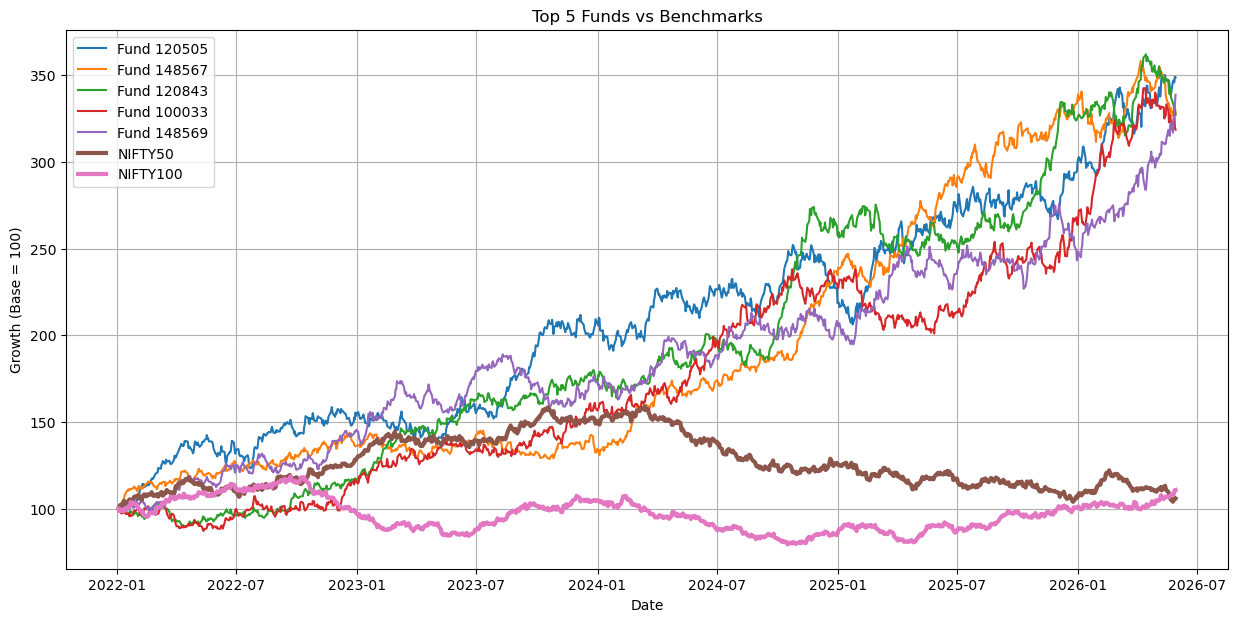

In [218]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,7))

for code in top5:

    fund = top5_nav[
        top5_nav["amfi_code"] == code
    ]

    plt.plot(
        fund["date"],
        fund["growth"],
        label=f"Fund {code}"
    )

plt.plot(
    nifty50["date"],
    nifty50["growth"],
    linewidth=3,
    label="NIFTY50"
)

plt.plot(
    nifty100["date"],
    nifty100["growth"],
    linewidth=3,
    label="NIFTY100"
)

plt.legend()
plt.xlabel("Date")
plt.ylabel("Growth (Base = 100)")
plt.title("Top 5 Funds vs Benchmarks")
plt.grid(True)

plt.show()

In [219]:
# chart will show all starting from 100.

# Part 2: Tracking Error

In [224]:
# other process done in instruction 5th

In [225]:
# Calculate Benchmark Returns & Merge (we already done in instruction 5th)

In [222]:
merged["difference"] = (
    merged["daily_return"]
    -
    merged["benchmark_return"]
)

In [223]:
merged["difference"]

1        0.003234
2        0.008862
3       -0.008442
4       -0.007360
5       -0.000288
           ...   
45995    0.009375
45996   -0.003226
45997   -0.022062
45998   -0.037777
45999   -0.004266
Name: difference, Length: 45960, dtype: float64

In [226]:
# Step 4: Tracking Error

In [227]:
tracking_error = (
    merged.groupby("amfi_code")["difference"]
            .std()
            .mul(252**0.5)
            .reset_index()
)

In [228]:
tracking_error.columns = [
    "amfi_code",
    "tracking_error"
]

In [231]:
tracking_error.columns

Index(['amfi_code', 'tracking_error'], dtype='object')

# Step 5: Merge into Scorecard (Optional)

In [232]:
scorecard = scorecard.merge(
    tracking_error,
    on="amfi_code"
)

In [238]:
scorecard.head()

,amfi_code,return_3yr,sharpe,annual_alpha,peak_date,trough_date,max_drawdown,expense_ratio_pct,return_rank,sharpe_rank,alpha_rank,expense_rank,drawdown_rank,return_score,sharpe_score,alpha_score,expense_score,drawdown_score,fund_score,tracking_error
0,120505,2.486841,1.180,0.292636,2024-10-24,2025-01-23,-0.181885,1.36,1.0,5.0,3.0,15.0,25.0,100.000000,89.743590,94.871795,64.102564,38.461538,84.871795,0.231968
1,148567,2.277811,1.448,0.269838,2023-07-11,2023-10-20,-0.112657,1.46,5.0,1.0,7.0,23.0,8.0,89.743590,100.000000,84.615385,43.589744,82.051282,83.589744,0.189664
2,120843,2.270478,1.307,0.273305,2022-03-07,2022-04-13,-0.129740,1.45,6.0,2.0,5.0,22.0,13.0,87.179487,97.435897,89.743590,46.153846,69.230769,82.307692,0.206425
3,100033,2.185142,1.094,0.271954,2022-03-11,2022-05-12,-0.162172,1.38,7.0,7.0,6.0,17.0,20.0,84.615385,84.615385,87.179487,58.974359,51.282051,77.948718,0.228699
4,148569,2.386581,1.235,0.282704,2023-08-10,2023-10-20,-0.163967,1.60,4.0,3.0,4.0,36.5,21.0,92.307692,94.871795,92.307692,8.974359,48.717949,76.089744,0.217365


# Deliverables: Performance_Analytics.ipynb, fund_scorecard.csv, alpha_beta.csv, benchmark comparison chart PNG

In [234]:
# 2. fund_scorecard.csv

#After creating the scorecard:

In [249]:
scorecard.columns

Index(['amfi_code', 'return_3yr', 'Sharpe_Ratio', 'Alpha', 'peak_date',
       'trough_date', 'max_drawdown', 'expense_ratio', 'return_rank',
       'sharpe_rank', 'alpha_rank', 'expense_rank', 'drawdown_rank',
       'return_score', 'sharpe_score', 'alpha_score', 'expense_score',
       'drawdown_score', 'Fund_Score', 'tracking_error', 'scheme_name'],
      dtype='object')

In [239]:
# Step 1: Rename the columns

In [241]:
scorecard = scorecard.rename(columns={
    "sharpe": "Sharpe_Ratio",
    "annual_alpha": "Alpha",
    "expense_ratio_pct": "expense_ratio",
    "fund_score": "Fund_Score"
})

In [244]:
scorecard = scorecard.merge(
    fund_master[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

In [245]:
# Keep only the required columns

In [247]:
fund_scorecard = scorecard[
    [
        "amfi_code",
        "scheme_name",
        "return_3yr",
        "Sharpe_Ratio",
        "Alpha",
        "expense_ratio",
        "max_drawdown",
        "Fund_Score"
    ]
]

In [248]:
fund_scorecard.head()

,amfi_code,scheme_name,return_3yr,Sharpe_Ratio,Alpha,expense_ratio,max_drawdown,Fund_Score
0,120505,ICICI Pru Midcap Fund - Regular - Growth,2.486841,1.180,0.292636,1.36,-0.181885,84.871795
1,148567,Mirae Asset Large Cap Fund - Regular - Growth,2.277811,1.448,0.269838,1.46,-0.112657,83.589744
2,120843,Kotak Flexicap Fund - Regular - Growth,2.270478,1.307,0.273305,1.45,-0.129740,82.307692
3,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,2.185142,1.094,0.271954,1.38,-0.162172,77.948718
4,148569,Mirae Asset Tax Saver Fund - Regular - Growth,2.386581,1.235,0.282704,1.60,-0.163967,76.089744


In [251]:
fund_scorecard.to_csv(
    "fund_scorecard.csv",
    index=False
)

# 3. alpha_beta.csv

#After calculating Alpha and Beta:

In [253]:
alpha_beta.columns

Index(['amfi_code', 'beta', 'daily_alpha', 'annual_alpha', 'r_squared',
       'p_value'],
      dtype='object')

In [254]:
#Step 1: Rename the required columns

In [255]:
alpha_beta = alpha_beta.rename(columns={
    "annual_alpha": "Alpha",
    "beta": "Beta"
})

In [256]:
# Step 2: Merge with scheme_master

In [257]:
alpha_beta = alpha_beta.merge(
    fund_master[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

In [258]:
#Step 3: Keep only the required columns

In [259]:
alpha_beta = alpha_beta[
    ["amfi_code", "scheme_name", "Alpha", "Beta"]
]

In [260]:
alpha_beta.head()

,amfi_code,scheme_name,Alpha,Beta
0,100016,HDFC Top 100 Fund - Regular Plan - Growth,0.037476,-0.058268
1,100025,HDFC Short Term Debt Fund - Regular - Growth,0.042818,0.001158
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,0.271954,0.005104
3,101206,ABSL Frontline Equity Fund - Regular - Growth,0.213998,0.021086
4,101207,ABSL Small Cap Fund - Regular - Growth,0.108971,-0.065289


In [261]:
# save the file

In [263]:
alpha_beta.to_csv(
    "alpha_beta.csv",
    index=False
)

# 4. benchmark_comparison.png

In [264]:
# After plotting the Top 5 funds with the benchmarks:

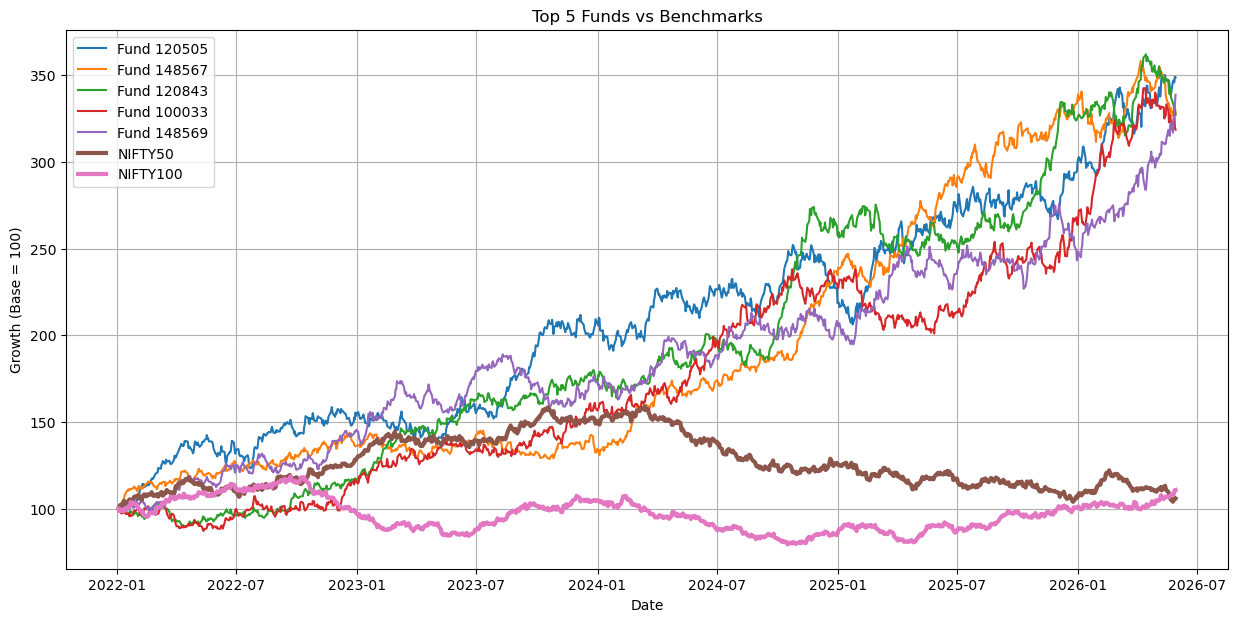

In [272]:
plt.figure(figsize=(15,7))

for code in top5:

    fund = top5_nav[
        top5_nav["amfi_code"] == code
    ]

    plt.plot(
        fund["date"],
        fund["growth"],
        label=f"Fund {code}"
    )

plt.plot(
    nifty50["date"],
    nifty50["growth"],
    linewidth=3,
    label="NIFTY50"
)

plt.plot(
    nifty100["date"],
    nifty100["growth"],
    linewidth=3,
    label="NIFTY100"
)

plt.legend()
plt.xlabel("Date")
plt.ylabel("Growth (Base = 100)")
plt.title("Top 5 Funds vs Benchmarks")
plt.grid(True)

plt.savefig(
    "benchmark_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [273]:
#save the png